In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.stats as ss
import rbo
import gzip
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import data_funcs
import xarray as xr
import correlation_funcs

In [2]:
drug_data, landmark_genes = data_funcs.read_drug_data()
dis_data = data_funcs.read_dis_data(landmark_genes)

In [3]:
df = correlation_funcs.get_correlations(drug_data, dis_data.iloc[:, 1], correlation_type=['pearson', 'spearman'])

In [7]:
df.values

array([[0.011937288747781185, 0.01921707140772659],
       [0.006720770428097606, 0.024725446814935634],
       [0.0006657876893526802, 0.020923726928267772],
       ...,
       [0.018829992695760765, 0.030175159441830603],
       [0.026828068140173467, 0.04521579377313165],
       [0.02884689166736847, 0.046341888422333624]], dtype=object)

In [3]:
arr_3d = correlation_funcs.get_correlations(drug_data, dis_data, correlation_type=['pearson', 'spearman'])

In [21]:
import h5py
with h5py.File('pear_spear_data.h5', 'w') as hf:
    hf.create_dataset('pear_data', data=arr_3d[:,:,0].astype('float32'))
    hf.create_dataset('spear_data', data=arr_3d[:,:,1].astype('float32'))

In [22]:
with h5py.File('pear_spear_data.h5', 'r') as hf:
    pear_data = hf['pear_data'][:]
    spear_data = hf['spear_data'][:]

In [23]:
pear_data

array([[-0.0018174 , -0.00394673, -0.01048301, ...,  0.02761343,
         0.03656544,  0.03536586],
       [ 0.01193729,  0.00672077,  0.00066579, ...,  0.01882999,
         0.02682807,  0.02884689],
       [ 0.00722821,  0.00287911, -0.00229869, ...,  0.02581145,
         0.03205302,  0.03291872],
       ...,
       [ 0.08109161,  0.09483786,  0.08358871, ...,  0.0879842 ,
         0.09711459,  0.09174628],
       [ 0.13989213,  0.15211315,  0.14607593, ...,  0.12016566,
         0.13265692,  0.13023044],
       [ 0.11843557,  0.12990198,  0.12352727, ...,  0.0839464 ,
         0.09454423,  0.11308744]], dtype=float32)

In [35]:
pairwise_df = pd.DataFrame(arr_3d[:,:,1].T, index=drug_data.columns, columns=dis_data.columns)
pairwise_df

Disease Samples,GSM484450,GSM484453,GSM484454,GSM484457,GSM484462,GSM484477,GSM484479,GSM409137,GSM409138,GSM409139,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
LJP005_A375_24H_B19:A03,0.012006,0.019217,0.012907,0.011462,0.020184,-0.001501,0.010571,0.000579,0.145007,0.164785,...,0.194006,0.1946,0.223416,0.215447,0.162112,0.198335,0.18396,0.202415,0.197768,0.223783
LJP005_A375_24H_B19:A04,0.01684,0.024725,0.012386,0.017089,0.02663,0.001649,0.016747,0.005947,0.156758,0.174741,...,0.201612,0.199734,0.23153,0.219938,0.172396,0.201464,0.197973,0.208565,0.207585,0.226206
LJP005_A375_24H_B19:A05,0.013852,0.020924,0.012551,0.014178,0.023941,0.001253,0.015406,-0.002561,0.142573,0.162493,...,0.184831,0.190361,0.216846,0.206254,0.159596,0.186756,0.187076,0.194945,0.197737,0.213726
LJP005_A375_24H_B19:A06,0.03071,0.037348,0.024943,0.028466,0.038737,0.015274,0.030169,-0.010331,0.142198,0.160418,...,0.185521,0.181353,0.212572,0.20303,0.158041,0.186208,0.178405,0.189853,0.188012,0.209791
LJP005_A375_24H_B19:B03,0.022237,0.028436,0.016735,0.024884,0.028596,0.007684,0.021749,0.00374,0.155948,0.176455,...,0.199714,0.200776,0.229282,0.218884,0.173005,0.202808,0.196565,0.209965,0.208456,0.220316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REP.A028_YAPC_24H_B25:J14,0.053174,0.034804,0.034437,0.04156,0.039809,0.019829,0.036278,0.062968,0.155915,0.169296,...,0.168475,0.1831,0.192436,0.20542,0.143855,0.173726,0.159271,0.190484,0.172755,0.227324
REP.A028_YAPC_24H_B25:J15,0.04609,0.034134,0.038735,0.043796,0.042696,0.028757,0.037158,0.055143,0.144163,0.159601,...,0.163347,0.17407,0.187897,0.206247,0.138703,0.171317,0.158842,0.183041,0.164263,0.217373
REP.A028_YAPC_24H_B25:J16,0.045472,0.030175,0.032287,0.034288,0.035161,0.018631,0.030371,0.068207,0.161025,0.173919,...,0.173866,0.180554,0.192028,0.201368,0.132771,0.168895,0.152531,0.190605,0.161104,0.21337
REP.A028_YAPC_24H_B25:J17,0.063613,0.045216,0.047244,0.054365,0.049734,0.034375,0.050796,0.057763,0.162179,0.174918,...,0.18471,0.194471,0.207936,0.222781,0.146922,0.184748,0.166649,0.197584,0.19331,0.24466


In [36]:
cell_lines = pd.Series(index=pairwise_df.index, dtype=str)
for drug_sample in pairwise_df.index:
    cell_lines[drug_sample] = drug_sample.split('_')[1]
unique_cell_lines = np.unique(cell_lines)

output = {}
for dis_sample in pairwise_df.columns:
    cell_line_means = pd.Series(index=unique_cell_lines)
    for cell_line in unique_cell_lines:
        cell_line_samples = cell_lines[cell_lines == cell_line].index
        cell_line_means[cell_line] = pairwise_df.loc[cell_line_samples, dis_sample].mean()
    cell_line_means.sort_values(ascending=False, inplace=True)
    output[dis_sample] = cell_line_means.index.values

In [37]:
spear_cell_line_ranks = pd.DataFrame(output.values(), index=output.keys()).T
spear_cell_line_ranks.to_csv('spear_cell_line_ranks.csv', index=False)

In [34]:
pear_cell_line_ranks = pd.DataFrame(output.values(), index=output.keys()).T
pear_cell_line_ranks.to_csv('pear_cell_line_ranks.csv', index=False)

In [45]:
pear_cell_line_ranks

,GSM484450,GSM484453,GSM484454,GSM484457,GSM484462,GSM484477,GSM484479,GSM409137,GSM409138,GSM409139,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
0,MNEU.E,JURKAT,JURKAT,JURKAT,JURKAT,JURKAT,JURKAT,HME1,HME1,HME1,...,ASC.C,ASC.C,ASC.C,CD34,ASC.C,ASC.C,ASC.C,ASC.C,SKBR3,CD34
1,JURKAT,MNEU.E,MNEU.E,MNEU.E,MNEU.E,MNEU.E,MNEU.E,MCF10A,MCF10A,CD34,...,MDAMB231,SKL,MDAMB231,MDAMB231,HME1,SKL,SKL,SKL,MCF10A,SKL
2,YAPC,YAPC,YAPC,YAPC,YAPC,YAPC,YAPC,SKL,CD34,SKL,...,SKL,SKL.C,SKL,SKL,SKL,MDAMB231,SKL.C,HME1,ASC.C,MDAMB231
3,HT29,HT29,HT29,HT29,HT29,HT29,HT29,HS578T,SKL,MCF10A,...,SKL.C,HME1,HME1,ASC.C,MCF10A,HME1,HME1,SKL.C,HME1,SKL.C
4,NEU,NPC.CAS9,NPC.CAS9,NPC.CAS9,NPC.CAS9,NPC.CAS9,NPC.CAS9,MDAMB231,HCC515,HCC515,...,CD34,MDAMB231,SKL.C,SKL.C,SKL.C,SKL.C,SKBR3,SKBR3,MDAMB231,HS578T
5,MCF7,NPC.TAK,HA1E,HA1E,NPC.TAK,NPC.TAK,NPC.TAK,A549,MDAMB231,MDAMB231,...,HME1,HS578T,MCF10A,HS578T,MDAMB231,MCF10A,MCF10A,ASC,LNCAP,ASC.C
6,NPC.CAS9,HA1E,PC3,NPC.TAK,HA1E,NPC,HA1E,HCC515,HS578T,A375,...,HS578T,MCF10A,HS578T,SKBR3,HS578T,SKBR3,MDAMB231,HUVEC,SKL.C,MCF10A
7,NPC.TAK,NPC,NPC.TAK,NPC,NPC,HA1E,NPC,SKBR3,A549,SKL.C,...,MCF10A,LNCAP,SKBR3,ASC,SKBR3,CD34,CD34,MCF10A,SKL,SKBR3
8,HA1E,A375,NPC,PC3,PC3,A375,NEU,HELA,SKBR3,HS578T,...,SKBR3,HUVEC,LNCAP,MCF10A,CD34,HS578T,HS578T,LNCAP,HS578T,HME1
9,NPC,PC3,A375,NEU,NEU,PC3,PC3,HUVEC,A375,A549,...,ASC,SKBR3,BT20,HME1,BT20,ASC,ASC,HS578T,HCC515,A549


In [47]:
df1 = pear_cell_line_ranks
df2 = spear_cell_line_ranks
output = pd.DataFrame(index=df1.index, columns=df1.columns)
for col in df1.columns:
    ranks = pd.Series(0, index=df1.iloc[:, 0])
    for row in df1.index:
        ranks[df1.loc[row, col]] += row
        ranks[df2.loc[row, col]] += row
    output[col] = ranks.sort_values(ascending=True).index
output.to_csv('combined_cell_line_ranks.csv', index=False)

In [34]:
xr_data = xr.Dataset()
for i in range(2):
    
    pd.DataFrame([[1+i*10,2+i*10,3+i*10],[4+i*10,5+i*10,6+i*10],[7+i*10,8+i*10,9+i*10]], columns=['a','b','c'], index=['x','y','z'])

In [2]:
# def get_pearson(dis_data, drug_data, dis_sample, drug_samples):
#     output = []
#     for drug_sample in drug_samples:
#         output.append(ss.pearsonr(*rm_na(dis_data.loc[:,dis_sample], drug_data.loc[:,drug_sample]))[0])
#     return np.array(output)

In [8]:
corr_matrix = pd.read_hdf('corr_matrix_11-19.h5', key='df')
pearson_matrix = corr_matrix.apply(lambda column: column.apply(lambda arr: arr[0]))
spearman_matrix = corr_matrix.apply(lambda column: column.apply(lambda arr: arr[1]))
rbo_matrix = corr_matrix.apply(lambda column: column.apply(lambda arr: arr[2]))
rbo_99_matrix = corr_matrix.apply(lambda column: column.apply(lambda arr: arr[3]))

dis_cell_line = pd.read_hdf('cell_types_df.h5', key='df')[['dis_cell', 'dis']].drop_duplicates(subset=['dis'], keep='first')
drug_cell_line = pd.read_hdf('cell_types_df.h5', key='df')[['drug_cell', 'drug']].drop_duplicates(subset=['drug'], keep='first')
uni_drug_cell_lines = drug_cell_line['drug_cell'].unique()

In [174]:
# RUN ALL LASSOS
dis_data_nona = dis_data.dropna(axis=0)
drug_data_nona = drug_data.loc[dis_data_nona.index]

X = drug_data_nona.values
best_alpha = .001
beta_matrix = pd.DataFrame(index=drug_data_nona.columns, columns=dis_data_nona.columns)

for dis_sample in dis_data_nona.columns:
    y = dis_data_nona[dis_sample].values
    lasso_model = Lasso(alpha=best_alpha)
    lasso_model.fit(X, y)
    betas = pd.Series(lasso_model.coef_, index=drug_data_nona.columns)
    beta_matrix.loc[:,dis_sample] = betas

/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.354e+02, tolerance: 1.324e+00
  model = cd_fast.enet_coordinate_descent(
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.621e+02, tolerance: 2.985e+00
  model = cd_fast.enet_coordinate_descent(
/Users/landon/anaconda3/envs/bio/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

In [176]:
beta_matrix.to_csv('beta_matrix.csv', sep=',', header=True, index=True)

In [4]:
beta_matrix = pd.read_csv('beta_matrix.csv', sep=',', header=0, index_col=0)

In [5]:
beta_matrix 

,GSM484450,GSM484453,GSM484454,GSM484457,GSM484462,GSM484477,GSM484479,GSM409137,GSM409138,GSM409139,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
LJP005_A375_24H_X1_B19:A03,0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.240191,0.188166,...,144.046384,135.266629,150.770188,248.493688,240.918749,306.399381,170.055712,175.537906,287.237143,249.332849
LJP005_A375_24H_X3_B19:N19,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.345814,0.180938,0.152975,...,57.622998,68.774352,37.613413,26.625214,57.573837,123.210176,62.170192,87.027370,114.982321,13.449202
LJP005_A375_24H_X3_B19:N20,-0.000000,0.076011,0.136820,0.087867,0.052973,0.117796,0.060417,0.066987,0.574005,0.690124,...,-2.618613,-2.536474,-0.689790,26.870943,-20.315646,-29.223052,12.116954,7.528196,1.889086,25.866995
LJP005_A375_24H_X3_B19:N21,-0.004236,-0.020242,-0.073620,-0.055344,-0.042625,-0.078333,-0.019393,0.000000,-0.271328,-0.272570,...,14.226507,27.916084,27.827636,-67.979951,91.069191,64.147845,69.003549,105.168890,21.085536,-76.397875
LJP005_A375_24H_X3_B19:N22,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.279275,-0.000000,-0.000000,...,-26.058071,-48.941663,-37.522201,13.467463,-138.531145,-93.683832,-86.573742,-151.348225,-73.773518,-55.488349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REP.A028_YAPC_24H_X1_B25:J14,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.273579,-0.026100,-0.000000,...,32.668623,10.884886,16.560898,85.141481,17.018088,32.134193,24.666120,4.840155,19.715116,44.094506
REP.A028_YAPC_24H_X1_B25:J15,-0.103209,-0.106948,-0.103875,-0.084470,-0.130572,-0.108232,-0.054047,0.000000,0.000000,0.114172,...,-8.265508,-3.745379,-8.016278,-16.368192,-0.182823,-14.621963,-27.244161,-1.062609,-0.887614,10.746293
REP.A028_YAPC_24H_X1_B25:J16,0.000000,0.041287,0.068333,0.059850,0.084690,0.120914,0.043479,0.000000,0.050476,0.119340,...,-21.909148,-15.881230,-18.815479,-21.085980,11.230199,15.111631,-7.811660,-21.652886,6.594905,-4.362270
REP.A028_YAPC_24H_X1_B25:J17,0.095638,0.188912,0.148315,0.154517,0.088938,0.106401,0.106043,0.202501,0.223821,0.197597,...,20.880369,13.896472,13.432094,39.111937,16.999988,30.545173,19.993207,11.949852,10.687122,29.965575


In [11]:
dis_sample = dis_data.columns[100]
drug_samples = drug_data.columns
df = pd.DataFrame({'drug_sample': drug_samples, 'betas': beta_matrix[dis_sample]})
df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
cell_lines = df['cell_line'].unique()

cell_line_to_mean_beta = pd.Series()
for cell_line in cell_lines:
    cell_line_to_mean_beta[cell_line] = df.loc[df['cell_line'] == cell_line, 'betas'].mean()
cell_line_to_mean_beta.sort_values(ascending=False, inplace=True)
print(cell_line_to_mean_beta[:3])

JURKAT    13.584989
CD34       5.519953
SKL        5.430162
dtype: float64


In [146]:
dis_sample = dis_data.columns[100]
drug_samples = drug_data.columns
df = pd.DataFrame({'drug_sample': drug_samples, 'pearson': pearson_matrix[dis_sample], 'spearman': spearman_matrix[dis_sample], 'rbo': rbo_matrix[dis_sample], 'rbo_99': rbo_99_matrix[dis_sample]})
df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
cell_lines = df['cell_line'].unique()

for cor in ['pearson', 'spearman', 'rbo', 'rbo_99']:
    cell_line_to_median_pear = pd.Series()
    for cell_line in cell_lines:
        cell_line_to_median_pear[cell_line] = df.loc[df['cell_line'] == cell_line, cor].median()
    cell_line_to_median_pear.sort_values(ascending=False, inplace=True)
    print(cell_line_to_median_pear[:3])


CD34     0.209149
SKL      0.112002
ASC.C    0.096791
dtype: float64
CD34      0.337347
SKL       0.202773
JURKAT    0.184025
dtype: float64
CD34     0.606843
SKL      0.565163
SKL.C    0.549066
dtype: float64
CD34        0.260024
MDAMB231    0.232816
SKL         0.215044
dtype: float64


In [19]:
top_cell_matrix = []
for dis_sample in dis_data.columns:
    drug_samples = drug_data.columns
    df = pd.DataFrame({'drug_sample': drug_samples, 'pearson': pearson_matrix[dis_sample], 'spearman': spearman_matrix[dis_sample], 'rbo': rbo_matrix[dis_sample], 'rbo_99': rbo_99_matrix[dis_sample]})
    df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
    cell_lines = df['cell_line'].unique()
    cell_codes = pd.Series(np.arange(len(cell_lines)), index=cell_lines)

    top_cell_lines = []
    for cor in ['pearson', 'spearman', 'rbo', 'rbo_99']:
        cell_line_to_median_pear = pd.Series()
        for cell_line in cell_lines:
            cell_line_to_median_pear[cell_line] = df.loc[df['cell_line'] == cell_line, cor].median()
        cell_line_to_median_pear.sort_values(ascending=False, inplace=True)
        top_cell_lines.append(cell_codes[cell_line_to_median_pear.index[0]])
    
    df = pd.DataFrame({'drug_sample': drug_samples, 'betas': beta_matrix[dis_sample]})
    df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
    cell_line_to_mean_beta = pd.Series()
    for cell_line in cell_lines:
        cell_line_to_mean_beta[cell_line] = df.loc[df['cell_line'] == cell_line, 'betas'].mean()
    cell_line_to_mean_beta.sort_values(ascending=False, inplace=True)
    top_cell_lines.append(cell_codes[cell_line_to_mean_beta.index[0]])
    top_cell_matrix.append(top_cell_lines)
top_cell_matrix = np.array(top_cell_matrix)


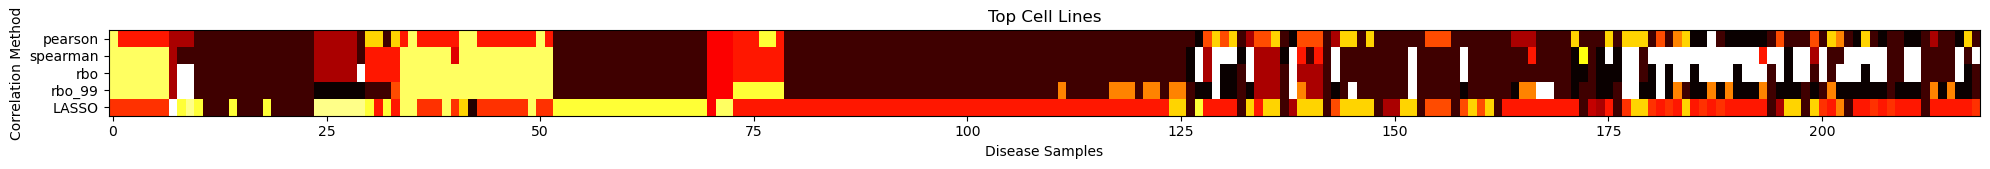

In [68]:
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(top_cell_matrix.T, cmap='hot')
ax.set_aspect(2)
ax.set_yticks(np.arange(5))
ax.set_yticklabels(['pearson', 'spearman', 'rbo', 'rbo_99', 'LASSO'])
ax.set_title("Top Cell Lines")
ax.set_xlabel("Disease Samples")
ax.set_ylabel("Correlation Method")
fig.tight_layout()
plt.show()

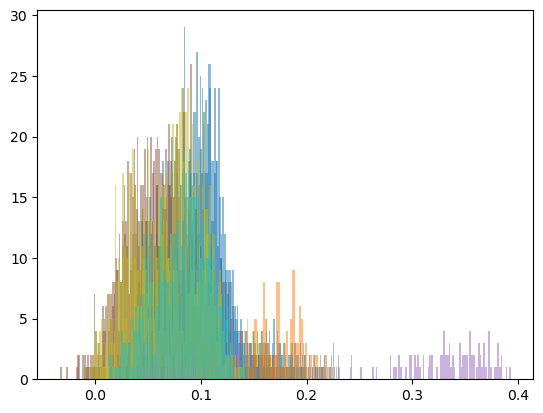

In [32]:
pears = spearman_matrix.iloc[:,100].values
df = pd.DataFrame({'drug_sample': drug_samples, 'spearman': pears})
df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
cell_lines = df['cell_line'].unique()
for cell_line in cell_lines:
    plt.hist(df.loc[df['cell_line'] == cell_line, 'spearman'], bins=100, alpha=0.5, label=cell_line)

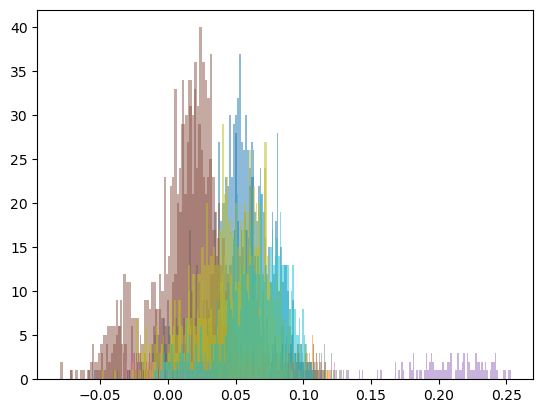

In [33]:
# Given a disease sample, frequency of drug sample correlations, grouped by cell line
pears = pearson_matrix.iloc[:,100].values
df = pd.DataFrame({'drug_sample': drug_samples, 'pearson': pears})
df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
cell_lines = df['cell_line'].unique()
for cell_line in cell_lines:
    plt.hist(df.loc[df['cell_line'] == cell_line, 'pearson'], bins=100, alpha=0.5, label=cell_line)

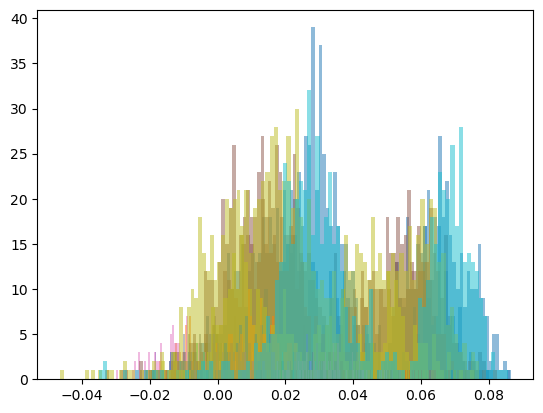

In [35]:
pears = pearson_matrix.iloc[:,1].values
df = pd.DataFrame({'drug_sample': drug_samples, 'pearson': pears})
df['cell_line'] = df['drug_sample'].apply(lambda x: x.split('_')[1])
cell_lines = df['cell_line'].unique()
for cell_line in cell_lines:
    plt.hist(df.loc[df['cell_line'] == cell_line, 'pearson'], bins=100, alpha=0.5, label=cell_line)

(array([  23.,  266., 1057., 1567., 1398.,  702.,  622.,  796.,  483.,
          75.]),
 array([-0.04343638, -0.02753048, -0.01162458,  0.00428131,  0.02018721,
         0.03609311,  0.05199901,  0.06790491,  0.0838108 ,  0.0997167 ,
         0.1156226 ]),
 <BarContainer object of 10 artists>)

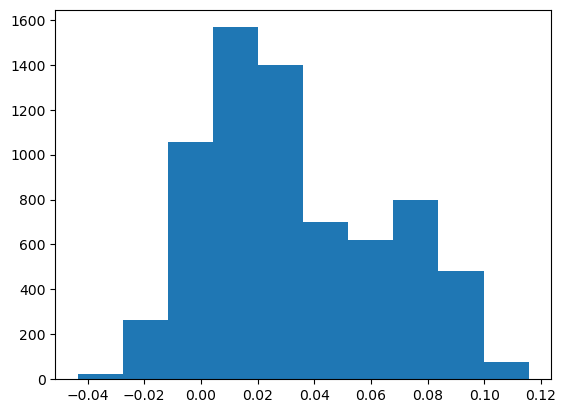

In [69]:
plt.hist(pears)

microarray


<Axes: >

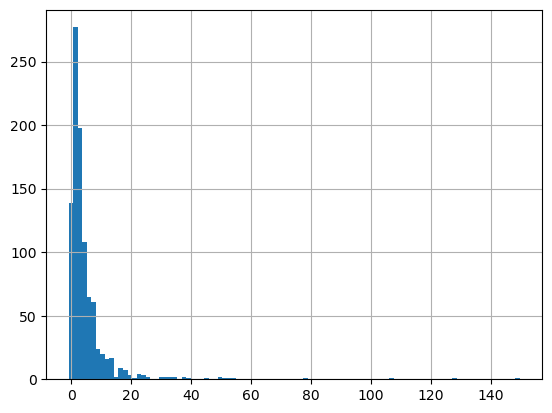

In [54]:
print(get_dis_meta(dis_data.columns[10], 'type'))
dis_data.iloc[:,10].hist(bins=100)

rnaseq


<Axes: >

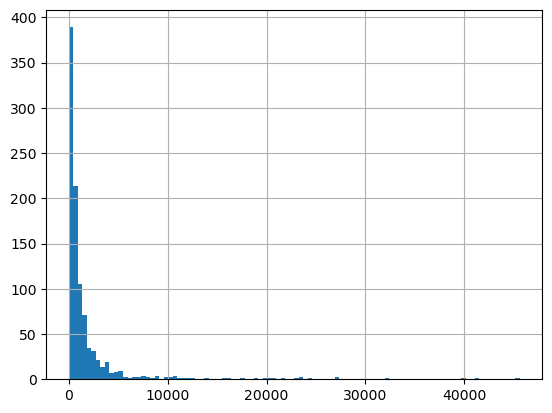

In [55]:
print(get_dis_meta(dis_data.columns[100], 'type'))
dis_data.iloc[:,100].hist(bins=100)

<Axes: >

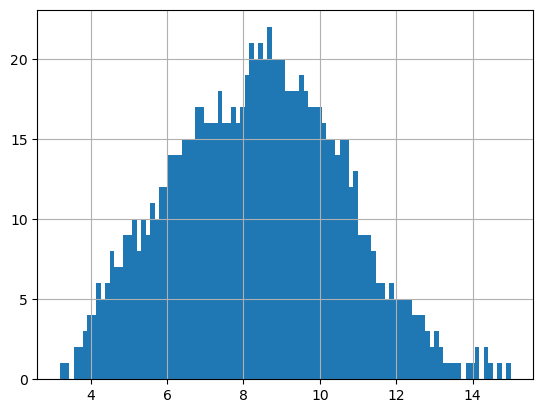

In [52]:
drug_data.iloc[:,100].hist(bins=100)

In [56]:
# def get_dis_cellline(dis_sample):
#     return str(pd.read_csv('dis_to_cell_line.csv', index_col=0).loc[dis_sample, '0'])

# dis_meta = pd.read_csv('dis_corr_edited.csv', sep=',', header=0)
# dis_meta.drop(columns=['corr'], inplace=True)
# dis_meta.rename(columns={'Disease Samples': 'dis_sample'}, inplace=True)
# dis_meta['cell_line'] = dis_meta['dis_sample'].apply(get_dis_cellline)
# dis_meta.to_csv('dis_meta.csv', sep=',', index=False)


In [ ]:
def calculate_pearson(subset_drug_data, dis_data):
    correlation_matrix = pd.DataFrame(index=subset_drug_data.columns, columns=dis_data.columns)
    for drug_sample in subset_drug_data.columns:
        sorted_drug_geneids = subset_drug_data.sort_values(by=drug_sample, ascending=False).index
        for dis_sample in dis_data.columns:
            # pearson
            corr = ss.pearsonr(*rm_na(subset_drug_data[drug_sample], dis_data[dis_sample]))[0]
            correlation_matrix.loc[drug_sample, dis_sample] = corr
    return correlation_matrix

def calculate_correlations(subset_drug_data, dis_data):
    correlation_matrix = pd.DataFrame(index=subset_drug_data.columns, columns=dis_data.columns)
    for drug_sample in subset_drug_data.columns:
        sorted_drug_geneids = subset_drug_data.sort_values(by=drug_sample, ascending=False).index
        for dis_sample in dis_data.columns:
            entry = np.array([np.nan, np.nan, np.nan, np.nan], dtype=float)
            # pearson
            corr = ss.pearsonr(*rm_na(subset_drug_data[drug_sample], dis_data[dis_sample]))[0]
            entry[0] = corr
            # spearman
            corr = ss.spearmanr(*rm_na(subset_drug_data[drug_sample], dis_data[dis_sample]))[0]
            entry[1] = corr
            # rbo
            sorted_dis_geneids = dis_data.sort_values(by=dis_sample, ascending=False).index
            corr = rbo.RankingSimilarity(*rm_na(sorted_drug_geneids, sorted_dis_geneids)).rbo()
            entry[2] = corr
            # rbo p=.99
            corr = rbo.RankingSimilarity(*rm_na(sorted_drug_geneids, sorted_dis_geneids)).rbo(p=.99)
            entry[3] = corr
            correlation_matrix.loc[drug_sample, dis_sample] = entry
    return correlation_matrix